<a href="https://colab.research.google.com/github/Victor0liveira/wine-quality-classification/blob/main/notebooks/analise_vinho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =============================================
# TECH CHALLENGE FASE 2 — Qualidade de Vinho
# =============================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# --- 1. CARREGA DADOS ---
path = '/content/drive/MyDrive/vinho/'
df = pd.read_csv(path + 'WineQT.csv')

print("✅ Dados carregados!")
print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstatísticas:\n{df.describe().round(2)}")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/vinho/WineQT.csv'

In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'wine' in file.lower() or 'vinho' in file.lower() or '.csv' in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/olist/archive 2/olist_customers_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_geolocation_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_items_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_payments_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_orders_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_order_reviews_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_products_dataset.csv
/content/drive/MyDrive/olist/archive 2/olist_sellers_dataset.csv
/content/drive/MyDrive/olist/archive 2/product_category_name_translation.csv
/content/drive/MyDrive/vinho /WineQT.csv


In [4]:
path = '/content/drive/MyDrive/vinho /WineQT.csv'
df = pd.read_csv(path)

In [5]:
# =============================================
# TECH CHALLENGE FASE 2 — Qualidade de Vinho
# =============================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# --- 1. CARREGA DADOS ---
path = '/content/drive/MyDrive/vinho /WineQT.csv'
df = pd.read_csv(path)

print("✅ Dados carregados!")
print(f"Shape: {df.shape}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstatísticas:\n{df.describe().round(2)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dados carregados!
Shape: (1143, 13)

Colunas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Estatísticas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count        1143.00           1143.00      1143.00         1143.00   
mean            8.31              0.53         0.27            2.53   
std             1.75              0.18 

📊 Distribuição das classes:
alta_qualidade
0    984
1    159
Name: count, dtype: int64

Alta qualidade (≥7): 159 vinhos (13.9%)
Baixa/média (<7):    984 vinhos (86.1%)


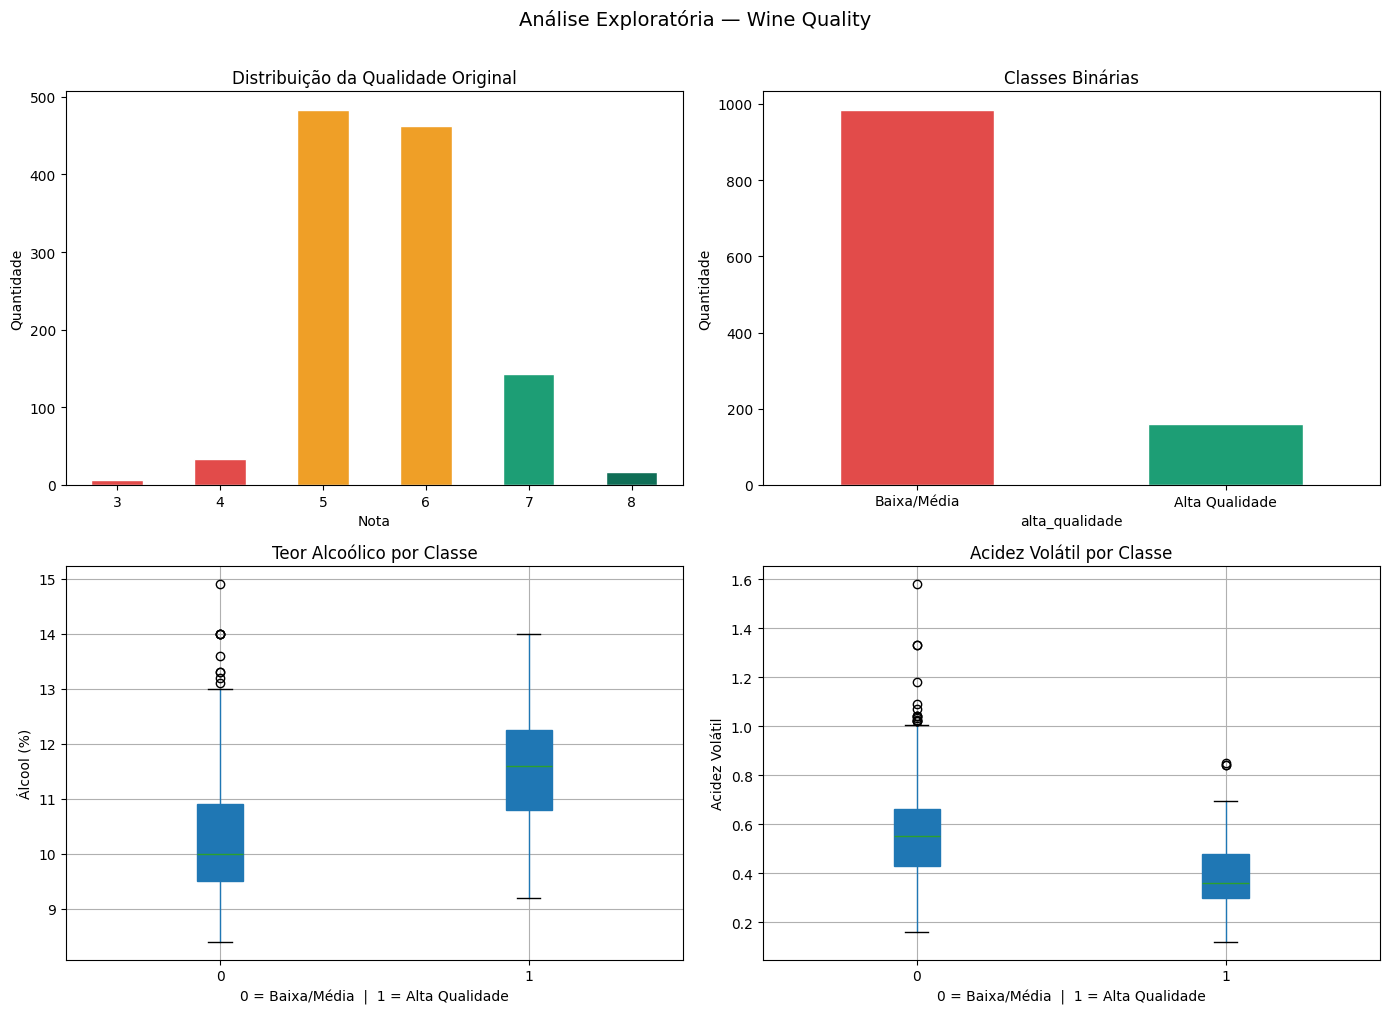

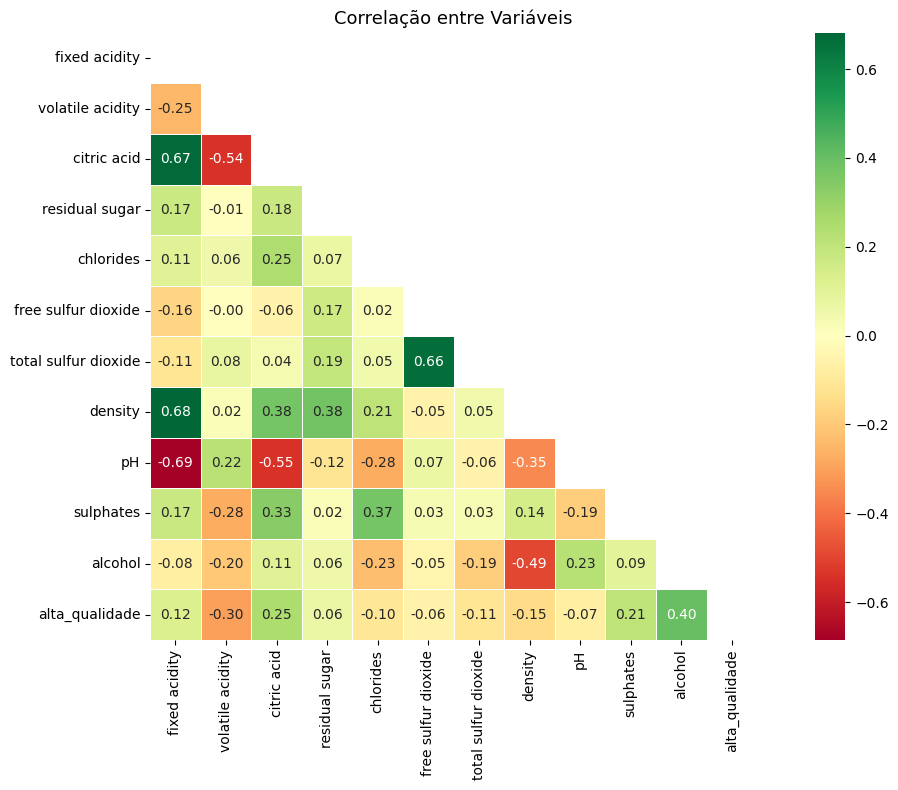


✅ Treino: 914 amostras | Teste: 229 amostras

📊 REGRESSÃO LOGÍSTICA:
                precision    recall  f1-score   support

   Baixa/Média       0.90      0.95      0.92       197
Alta Qualidade       0.52      0.34      0.42        32

      accuracy                           0.86       229
     macro avg       0.71      0.65      0.67       229
  weighted avg       0.85      0.86      0.85       229


📊 RANDOM FOREST:
                precision    recall  f1-score   support

   Baixa/Média       0.94      0.97      0.96       197
Alta Qualidade       0.79      0.59      0.68        32

      accuracy                           0.92       229
     macro avg       0.86      0.78      0.82       229
  weighted avg       0.92      0.92      0.92       229



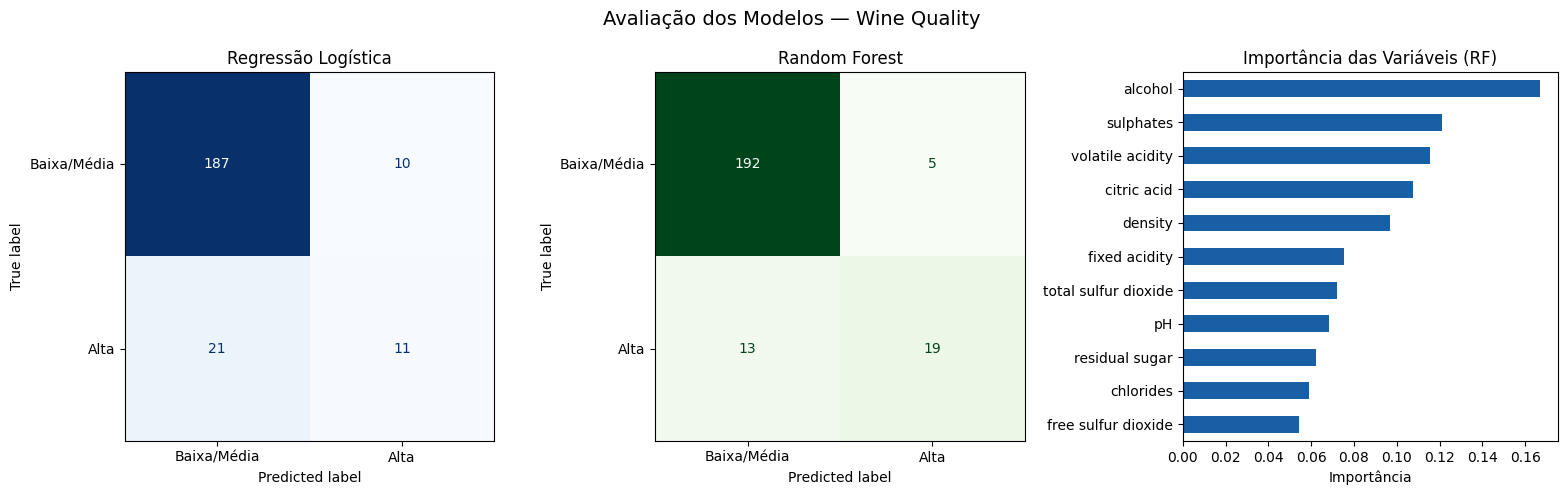

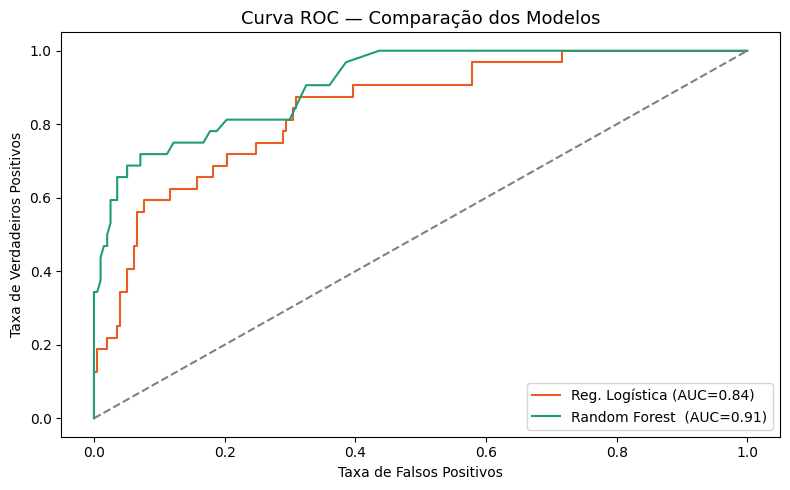


🏆 AUC Regressão Logística: 0.842
🏆 AUC Random Forest:       0.909


In [6]:
# --- 2. VARIÁVEL ALVO BINÁRIA ---
df['alta_qualidade'] = (df['quality'] >= 7).astype(int)

print("📊 Distribuição das classes:")
print(df['alta_qualidade'].value_counts())
print(f"\nAlta qualidade (≥7): {df['alta_qualidade'].sum()} vinhos ({df['alta_qualidade'].mean():.1%})")
print(f"Baixa/média (<7):    {(df['alta_qualidade']==0).sum()} vinhos ({1-df['alta_qualidade'].mean():.1%})")

# --- 3. EDA — GRÁFICOS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribuição da qualidade original
df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0],
    color=['#E24B4A','#E24B4A','#EF9F27','#EF9F27','#1D9E75','#0F6E56'],
    edgecolor='white')
axes[0,0].set_title('Distribuição da Qualidade Original', fontsize=12)
axes[0,0].set_xlabel('Nota'); axes[0,0].set_ylabel('Quantidade')
axes[0,0].tick_params(axis='x', rotation=0)

# Balanceamento binário
cores_bin = ['#E24B4A','#1D9E75']
df['alta_qualidade'].value_counts().plot(kind='bar', ax=axes[0,1],
    color=cores_bin, edgecolor='white')
axes[0,1].set_title('Classes Binárias', fontsize=12)
axes[0,1].set_xticklabels(['Baixa/Média','Alta Qualidade'], rotation=0)
axes[0,1].set_ylabel('Quantidade')

# Álcool vs Qualidade
df.boxplot(column='alcohol', by='alta_qualidade', ax=axes[1,0],
    patch_artist=True)
axes[1,0].set_title('Teor Alcoólico por Classe', fontsize=12)
axes[1,0].set_xlabel('0 = Baixa/Média  |  1 = Alta Qualidade')
axes[1,0].set_ylabel('Álcool (%)')
plt.sca(axes[1,0]); plt.title('Teor Alcoólico por Classe')

# Acidez volátil vs Qualidade
df.boxplot(column='volatile acidity', by='alta_qualidade', ax=axes[1,1],
    patch_artist=True)
axes[1,1].set_title('Acidez Volátil por Classe', fontsize=12)
axes[1,1].set_xlabel('0 = Baixa/Média  |  1 = Alta Qualidade')
axes[1,1].set_ylabel('Acidez Volátil')
plt.sca(axes[1,1]); plt.title('Acidez Volátil por Classe')

plt.suptitle('Análise Exploratória — Wine Quality', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_vinho.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 4. CORRELAÇÕES ---
plt.figure(figsize=(12, 8))
features = df.drop(columns=['quality', 'alta_qualidade', 'Id'])
corr = features.join(df['alta_qualidade']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlação entre Variáveis', fontsize=13)
plt.tight_layout()
plt.savefig('correlacao_vinho.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 5. PRÉ-PROCESSAMENTO ---
X = df.drop(columns=['quality', 'alta_qualidade', 'Id'])
y = df['alta_qualidade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

# --- 6. MODELOS ---
# Regressão Logística
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n📊 REGRESSÃO LOGÍSTICA:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Baixa/Média','Alta Qualidade']))

print("\n📊 RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf,
      target_names=['Baixa/Média','Alta Qualidade']))

# --- 7. GRÁFICOS DOS MODELOS ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriz de confusão - LR
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['Baixa/Média','Alta'], ax=axes[0], colorbar=False,
    cmap='Blues')
axes[0].set_title('Regressão Logística', fontsize=12)

# Matriz de confusão - RF
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['Baixa/Média','Alta'], ax=axes[1], colorbar=False,
    cmap='Greens')
axes[1].set_title('Random Forest', fontsize=12)

# Importância das variáveis
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importancias.plot(kind='barh', ax=axes[2], color='#185FA5')
axes[2].set_title('Importância das Variáveis (RF)', fontsize=12)
axes[2].set_xlabel('Importância')

plt.suptitle('Avaliação dos Modelos — Wine Quality', fontsize=14)
plt.tight_layout()
plt.savefig('modelos_vinho.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
auc_lr = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,5))
plt.plot(fpr_lr, tpr_lr, label=f'Reg. Logística (AUC={auc_lr:.2f})', color='#E85D24')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest  (AUC={auc_rf:.2f})', color='#1D9E75')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Comparação dos Modelos', fontsize=13)
plt.legend(); plt.tight_layout()
plt.savefig('roc_vinho.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 AUC Regressão Logística: {auc_lr:.3f}")
print(f"🏆 AUC Random Forest:       {auc_rf:.3f}")

In [7]:
print("=" * 50)
print("RESUMO EXECUTIVO — WINE QUALITY ML")
print("=" * 50)

print("\n📊 DATASET")
print(f"  Total de amostras: 1.143 vinhos")
print(f"  Alta qualidade (≥7): 159 vinhos (13,9%)")
print(f"  Baixa/Média (<7):  984 vinhos (86,1%)")
print(f"  Variáveis analisadas: 11 características físico-químicas")

print("\n🤖 MODELOS TESTADOS")
print(f"  Regressão Logística → Acurácia: 86% | AUC: 0,842")
print(f"  Random Forest       → Acurácia: 92% | AUC: 0,909 ✅ VENCEDOR")

print("\n🏆 TOP 3 FATORES QUE DEFINEM QUALIDADE")
print(f"  1. Teor alcoólico  — vinhos de alta qualidade têm ~12% álcool vs ~10%")
print(f"  2. Sulfatos        — níveis mais altos associados à alta qualidade")
print(f"  3. Acidez volátil  — vinhos ruins têm acidez volátil mais alta")

print("\n🎯 RECOMENDAÇÕES PARA PRODUTORES")
print(f"  • Monitorar teor alcoólico como principal indicador de qualidade")
print(f"  • Controlar acidez volátil durante fermentação")
print(f"  • Usar o modelo para triagem antes da avaliação humana")
print(f"  • Potencial de redução de custo: substituir parte das avaliações manuais")

RESUMO EXECUTIVO — WINE QUALITY ML

📊 DATASET
  Total de amostras: 1.143 vinhos
  Alta qualidade (≥7): 159 vinhos (13,9%)
  Baixa/Média (<7):  984 vinhos (86,1%)
  Variáveis analisadas: 11 características físico-químicas

🤖 MODELOS TESTADOS
  Regressão Logística → Acurácia: 86% | AUC: 0,842
  Random Forest       → Acurácia: 92% | AUC: 0,909 ✅ VENCEDOR

🏆 TOP 3 FATORES QUE DEFINEM QUALIDADE
  1. Teor alcoólico  — vinhos de alta qualidade têm ~12% álcool vs ~10%
  2. Sulfatos        — níveis mais altos associados à alta qualidade
  3. Acidez volátil  — vinhos ruins têm acidez volátil mais alta

🎯 RECOMENDAÇÕES PARA PRODUTORES
  • Monitorar teor alcoólico como principal indicador de qualidade
  • Controlar acidez volátil durante fermentação
  • Usar o modelo para triagem antes da avaliação humana
  • Potencial de redução de custo: substituir parte das avaliações manuais
